# Preguntas y Graficos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

server   = r'LAPTOP-LK9MMHNU\SQLEXPRESS'
database = 'SuperstoreRetail'
driver   = 'ODBC Driver 17 for SQL Server'

conn_str = f'mssql+pyodbc://{server}/{database}?trusted_connection=yes&driver={driver}'
engine   = create_engine(conn_str)

# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
print("Conexión exitosa ✅")

Conexión exitosa ✅


### 1. ¿Cuáles son las 10 ciudades con mayores ventas totales?

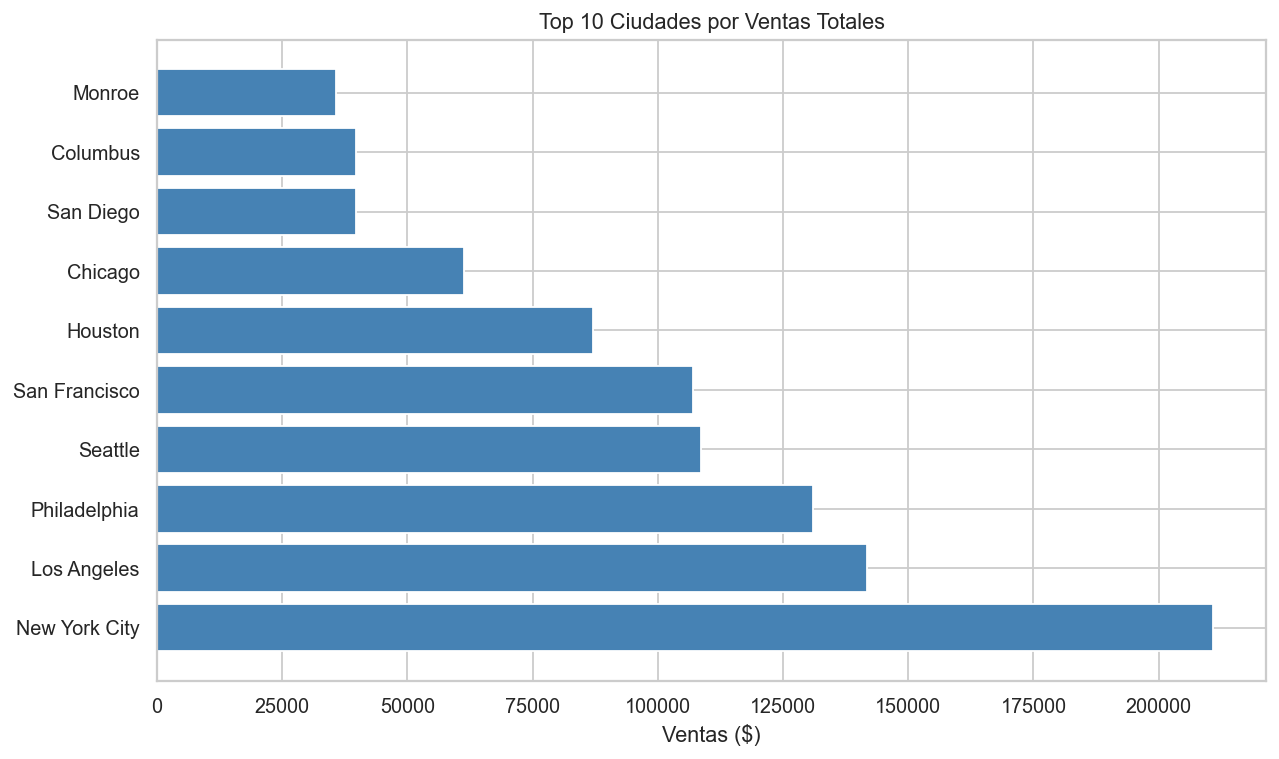

 La ciudad con mayores ventas es: New York City con $210,926.99


In [22]:
query = """
    SELECT TOP 10 c.city, SUM(s.sales) AS total_sales
    FROM Sales s
    JOIN Customers c ON s.customer_id = c.customer_id
    GROUP BY c.city
    ORDER BY total_sales desc
"""


# Con with → se cierra solo siempre ✅
with engine.connect() as conn:
    df_top_ciudad = pd.read_sql(query, conn)
# aquí la conexión ya se cerró automáticamente

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_top_ciudad['city'], df_top_ciudad['total_sales'], color='steelblue')
ax.set_title('Top 10 Ciudades por Ventas Totales')
ax.set_xlabel('Ventas ($)')
plt.tight_layout()
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ 1_top10_ciudades.png', dpi=150)
plt.show()
print(f" La ciudad con mayores ventas es: {df_top_ciudad['city'].iloc[0]} con ${df_top_ciudad['total_sales'].iloc[0]:,.2f}")


## 2 ¿Qué categoría genera más ventas y cuál más profit?

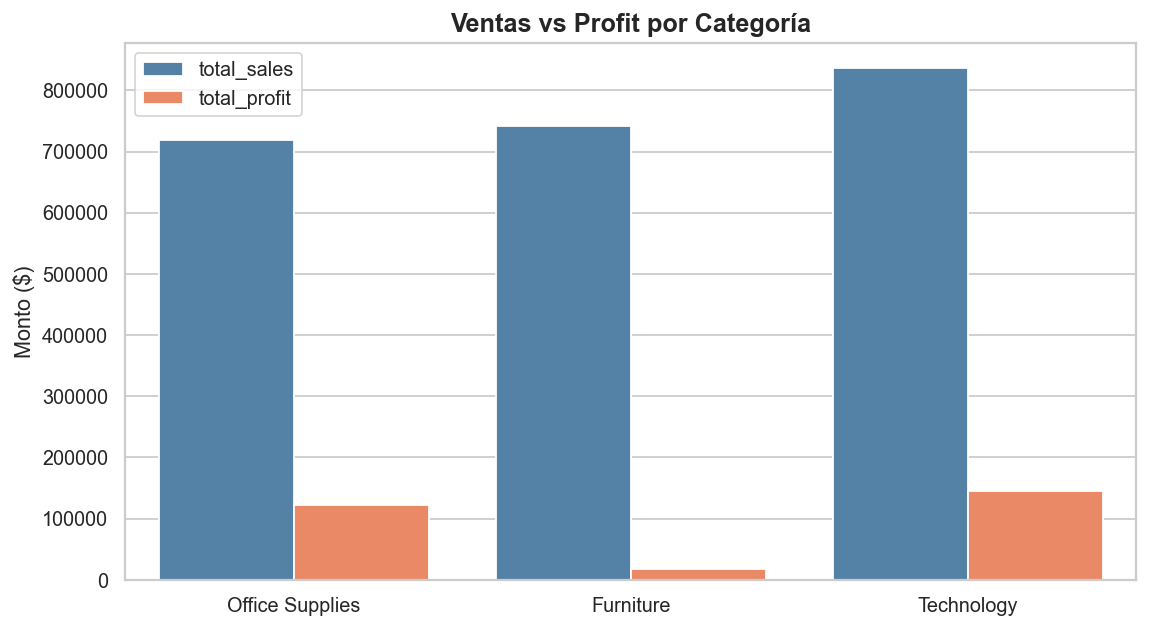

In [23]:
query = """
    SELECT p.category,
           SUM(s.sales)  AS total_sales,
           SUM(s.profit) AS total_profit
    FROM Sales s
    JOIN Products p ON s.product_id = p.product_id
    GROUP BY p.category
"""
df_q2 = pd.read_sql(query, engine)
df_q2_melted = df_q2.melt(id_vars='category', var_name='metrica', value_name='valor')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_q2_melted, x='category', y='valor', hue='metrica', palette=['steelblue','coral'], ax=ax)
ax.set_title('Ventas vs Profit por Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Monto ($)')
ax.legend(title='')
plt.tight_layout()
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ 2_ventas_profit_categoria.png')
plt.show()


## 3 ¿Cuál es la subcategoría más rentable y cuál genera pérdidas?

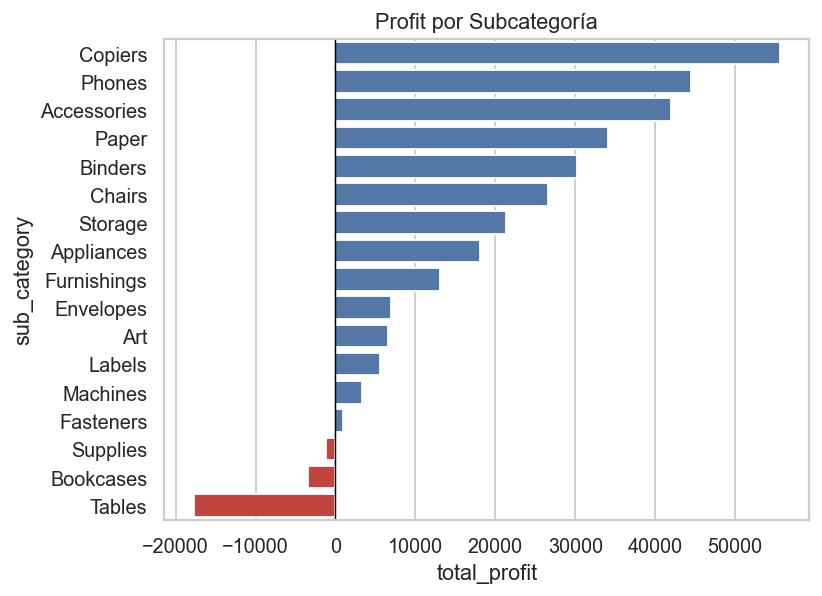

In [30]:
query="""
        SELECT p.sub_category, SUM(s.profit) AS total_profit
        FROM Sales s JOIN Products p ON s.product_id = p.product_id
        GROUP BY p.sub_category ORDER BY total_profit DESC
    """

with engine.connect() as conn:
    df_p3 = pd.read_sql(query, conn)

colors = ['#d73027' if x < 0 else '#4575b4' for x in df_p3['total_profit']]
sns.barplot(x='total_profit', y='sub_category', data=df_p3,
            hue='sub_category', palette=colors, legend=False)
plt.title('Profit por Subcategoría')
plt.axvline(0, color='black', lw=0.8)
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ 3_subcategoria.png', dpi=150)
plt.show()

## 4  ¿Qué segmento de clientes genera más ingresos?

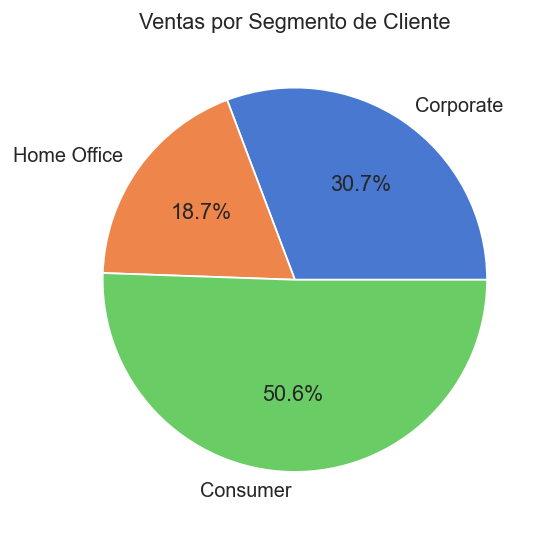

In [35]:
with engine.connect() as conn:
    df_p4 = pd.read_sql("""
        SELECT c.segment, SUM(s.sales) AS total_sales
        FROM Sales s JOIN Customers c ON s.customer_id = c.customer_id
        GROUP BY c.segment
    """, conn)

plt.pie(df_p4['total_sales'],
        labels=df_p4['segment'],
        autopct='%1.1f%%',
        colors=sns.color_palette('muted'))
plt.title('Ventas por Segmento de Cliente')
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ 4_segmento.png', dpi=150)
plt.show()

## 5 ¿Quiénes son los top 10 clientes por ventas?

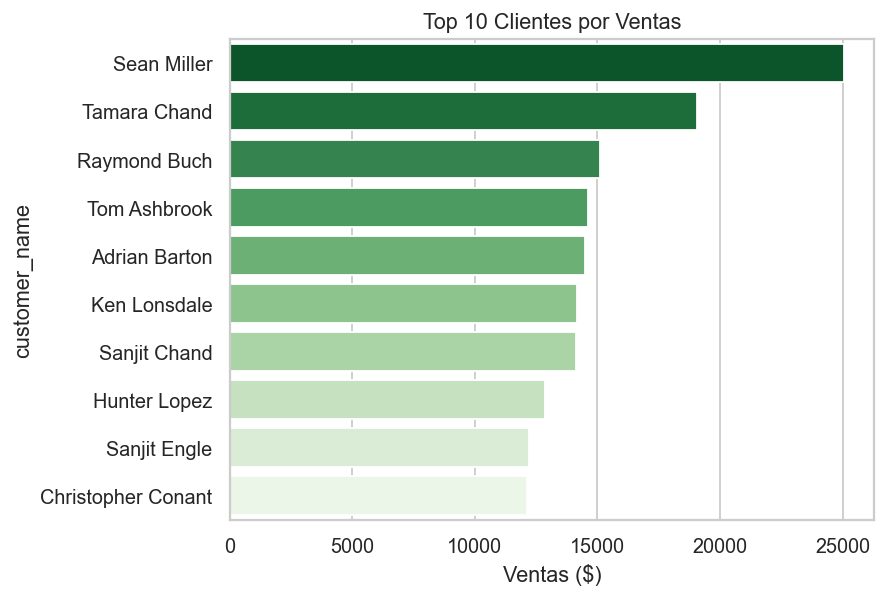

In [38]:
with engine.connect() as conn:
    df_p5 = pd.read_sql("""
        SELECT TOP 10 c.customer_name, SUM(s.sales) AS total_sales
        FROM Sales s JOIN Customers c ON s.customer_id = c.customer_id
        GROUP BY c.customer_name ORDER BY total_sales DESC
    """, conn)

sns.barplot(x='total_sales', y='customer_name', data=df_p5, palette='Greens_r', hue='customer_name', legend=False)
plt.title('Top 10 Clientes por Ventas')
plt.xlabel('Ventas ($)')
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ 5_topclientes.png', dpi=150)
plt.show()

## 6 ¿Cómo evolucionaron las ventas mes a mes?

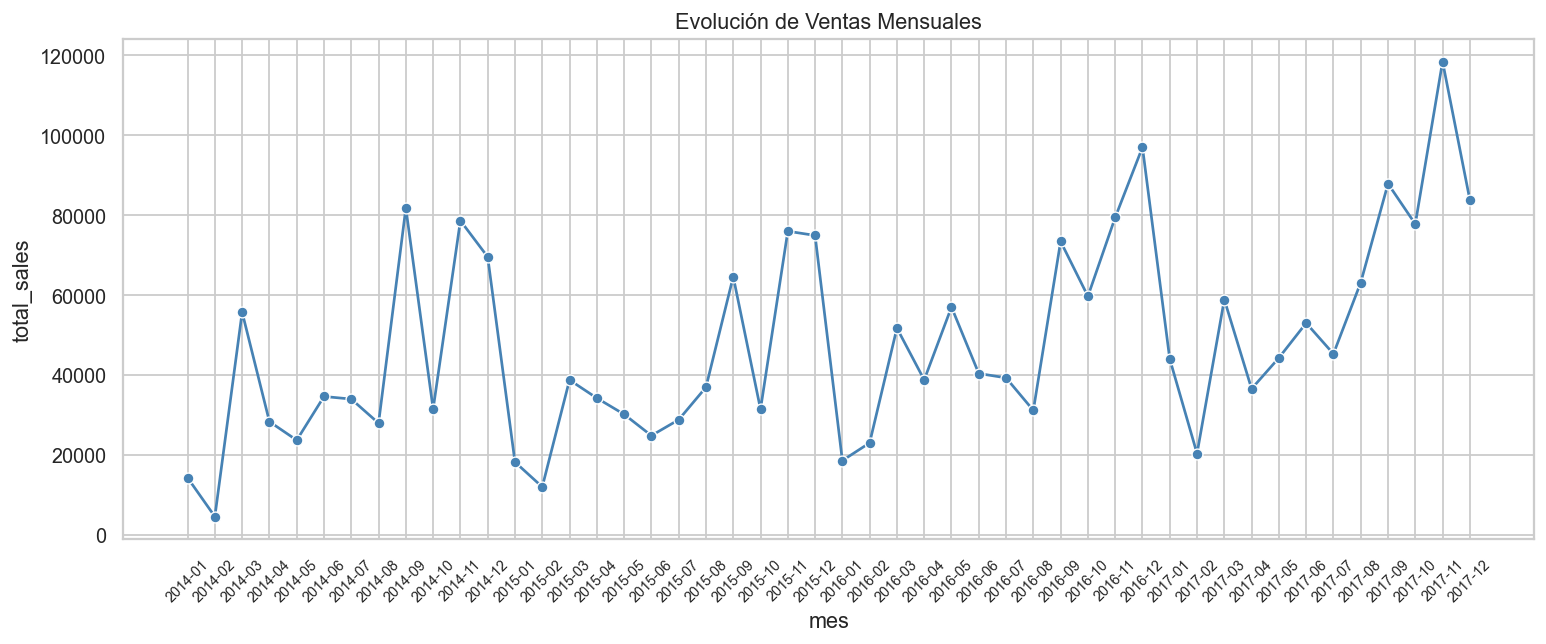

In [42]:
with engine.connect() as conn:
    df_p6 = pd.read_sql("""
        SELECT FORMAT(order_date,'yyyy-MM') AS mes, SUM(sales) AS total_sales
        FROM Sales GROUP BY FORMAT(order_date,'yyyy-MM') ORDER BY mes
    """, conn)
fig, ax = plt.subplots(figsize=(14,5))     
sns.lineplot(x='mes', y='total_sales', data=df_p6, marker='o', color='steelblue')
plt.title('Evolución de Ventas Mensuales')
plt.xticks(rotation=45, fontsize=8)
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ 6_tendencia.png', dpi=150)
plt.show()

In [43]:
#Obteniendo de 1_Limpieza_data.ipynb para utilizar variables
%run "D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\1_Limpieza_data.ipynb"

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>


## 7 ¿En qué mes del año se vende más?

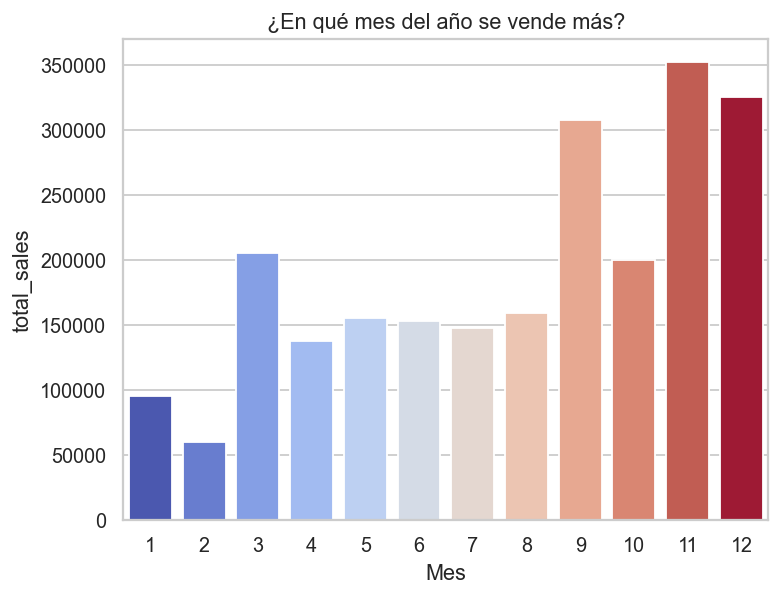

In [50]:
df_sales['order_date'] = pd.to_datetime(df_sales['Order Date'])
df_sales['mes'] = df_sales['order_date'].dt.month_name()
df_p7 = df_sales.groupby(df_sales['order_date'].dt.month)['Sales'].sum().reset_index()
df_p7.columns = ['mes', 'total_sales']

sns.barplot(x='mes', y='total_sales', data=df_p7,
            hue='mes', palette='coolwarm', legend=False)
plt.title('¿En qué mes del año se vende más?')
plt.xlabel('Mes')
plt.savefig(r'D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\7_mes_venta.png', dpi=150)
plt.show()




## 8 ¿Los descuentos altos generan pérdidas de profit?

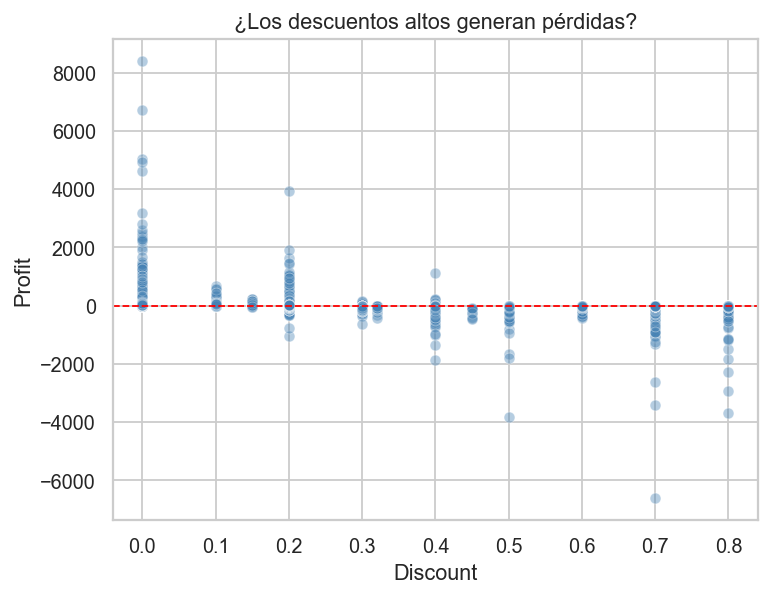

In [54]:
sns.scatterplot(x='Discount', y='Profit', data=df_sales, alpha=0.4, color='steelblue')
plt.title('¿Los descuentos altos generan pérdidas?')
plt.axhline(0, color='red', lw=1, ls='--')
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ p8_scatter.png', dpi=150)
plt.show()

## 9 ¿Qué modo de envío es el más usado?

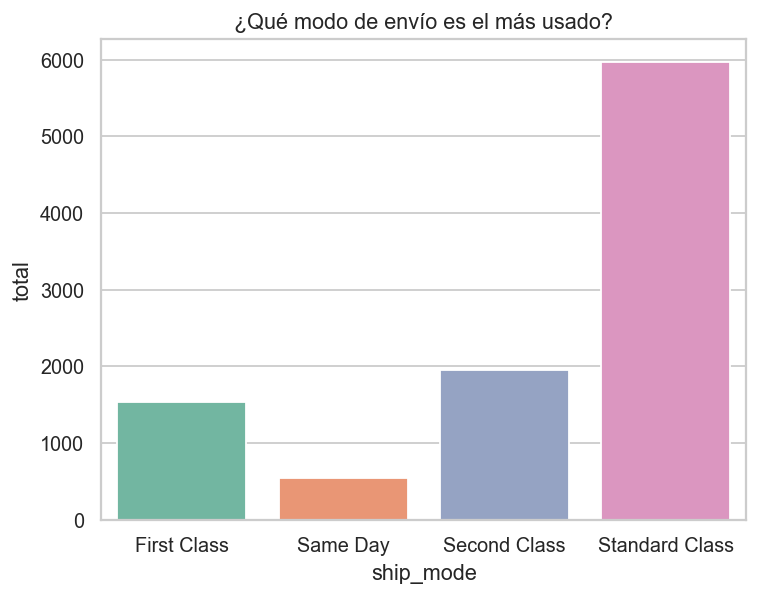

In [ ]:
df_p9 = df_sales.groupby('Ship Mode')['Row ID'].count().reset_index()
df_p9.columns = ['ship_mode', 'total']

sns.barplot(x='ship_mode', y='total', data=df_p9,
            hue='ship_mode', palette='Set2', legend=False)
plt.title('¿Qué modo de envío es el más usado?')
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\ p9_shipmode.png', dpi=150)
plt.show()

## 10 ¿Cuál es la región con mejor ratio profit/ventas?

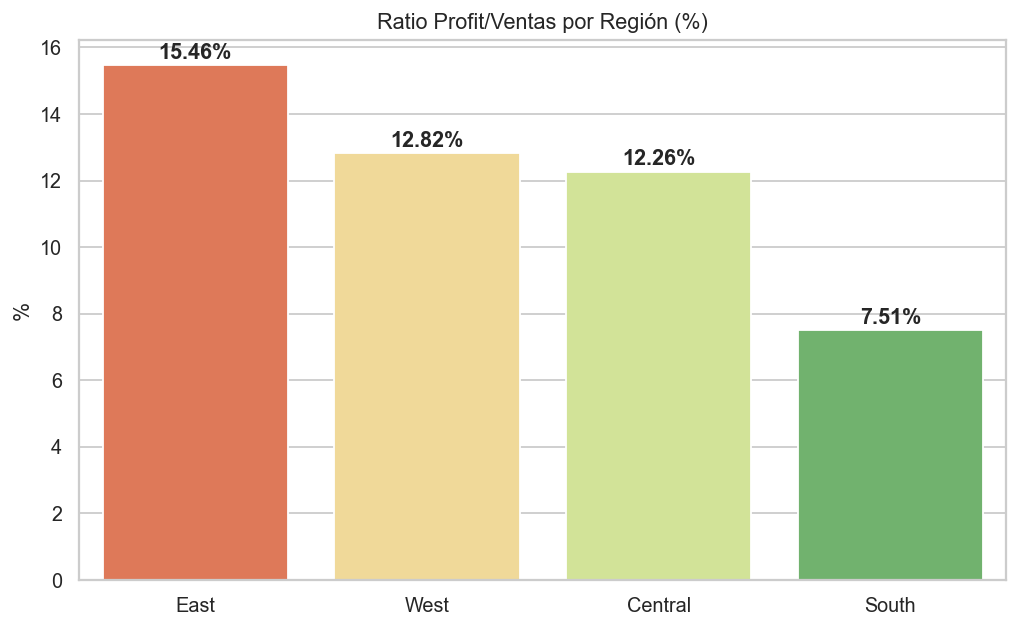

In [ ]:
with engine.connect() as conn:
    df = pd.read_sql("SELECT c.region, ROUND(SUM(s.profit)/SUM(s.sales)*100,2) AS ratio FROM Sales s JOIN Customers c ON s.customer_id=c.customer_id GROUP BY c.region ORDER BY ratio DESC", conn)

fig, ax = plt.subplots(figsize=(8,5))                                         
(sns.barplot(data=df, x='region', y='ratio',
            hue='region', palette='RdYlGn', legend=False, ax=ax))       
(ax.set(title='Ratio Profit/Ventas por Región (%)', xlabel='', ylabel='%'))   
[ax.text(i, v+0.2, f'{v}%', ha='center', fontweight='bold')                  
 for i, v in enumerate(df['ratio'])]
plt.tight_layout(); 
plt.savefig('D:\Proyectos\PYTHON\Project-Superstore-Retail-Analysis\picture\  10_region.png', dpi=150); 
plt.show() 